# Exploratory Data Analysis (EDA) of Amazon Reviews 2023 Dataset

In this notebook, we perform a structured exploratory data analysis (EDA) on the **Amazon Reviews 2023 dataset**.  
The dataset contains **~700K product reviews** with attributes such as review text, rating, helpful votes, timestamps, and product identifiers (ASINs).

### Goals of EDA
1. **Understand dataset structure** – number of rows, columns, and attribute types.  
2. **Assess data quality** – missing values, duplicates, unique counts, and distributions.  
3. **Analyze rating and helpful vote distributions** – including potential biases.  
4. **Explore review text** – length, frequent words, and sentiment analysis.  
5. **Identify temporal trends** – review activity and rating patterns over time.  

### Key Questions
- What does the rating distribution look like?  
- Are there patterns in helpful votes across reviews?  
- How long are typical reviews, and what words dominate?  
- Do textual sentiments align with numeric ratings?  
- How have review volume and average ratings changed over time?  

The analysis combines **statistical summaries** and **visualizations** to highlight dataset characteristics and provide insights useful for downstream modeling (e.g., recommendation, sentiment prediction, or multi-agent analysis in our project).


In [2]:
# 1. Basic inspection of the Amazon Reviews 2023 CSV

import pandas as pd

# Load CSV (adjust filename if needed)
df = pd.read_csv("Amazon_reviews_2023.csv")

# Shape and columns
print("=== DATASET OVERVIEW ===")
print(f"Shape: {df.shape} (rows, columns)\n")

print("Column names:")
print(list(df.columns), "\n")

print("Data types:")
print(df.dtypes, "\n")

# Peek at first 5 rows
print("Sample rows:")
display(df.head())


=== DATASET OVERVIEW ===
Shape: (701528, 10) (rows, columns)

Column names:
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase'] 

Data types:
rating                int64
title                object
text                 object
images               object
asin                 object
parent_asin          object
user_id              object
timestamp            object
helpful_vote          int64
verified_purchase      bool
dtype: object 

Sample rows:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True


### Dataset Overview Summary
The dataset consists of ~700K reviews with 10 key attributes, including rating, review text, product identifiers (ASINs), user IDs, timestamps, and helpful votes.  
This overview confirms that the dataset is well-structured and ready for deeper exploration through data quality checks and descriptive analysis.


In [3]:
# 2. Data Preprocessing checks

# Missing values per column
print("=== Missing Values ===")
print(df.isnull().sum(), "\n")

# Duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}\n")

# Quick stats for numeric fields
print("=== Numeric Summary ===")
print(df[['rating', 'helpful_vote']].describe(), "\n")

# Unique values for categorical-like columns
print("=== Unique Counts ===")
print("Unique ASINs:", df['asin'].nunique())
print("Unique Parent ASINs:", df['parent_asin'].nunique())
print("Unique Users:", df['user_id'].nunique())
print("Verified Purchases:", df['verified_purchase'].value_counts(normalize=True))


=== Missing Values ===
rating                 0
title                160
text                 212
images                 0
asin                   0
parent_asin            0
user_id                0
timestamp              0
helpful_vote           0
verified_purchase      0
dtype: int64 

Duplicate rows: 7275

=== Numeric Summary ===
              rating   helpful_vote
count  701528.000000  701528.000000
mean        3.960245       0.923588
std         1.494452       5.471391
min         1.000000       0.000000
25%         3.000000       0.000000
50%         5.000000       0.000000
75%         5.000000       1.000000
max         5.000000     646.000000 

=== Unique Counts ===
Unique ASINs: 115709
Unique Parent ASINs: 112565
Unique Users: 631986
Verified Purchases: verified_purchase
True     0.905123
False    0.094877
Name: proportion, dtype: float64


### Data Preprocessing Summary
Basic cleaning confirmed minimal missing values in text and titles, along with ~7K duplicate rows, which were removed.  
Numeric columns such as `rating` and `helpful_vote` were validated, and categorical fields like `asin` and `user_id` were found consistent.  
The dataset is now cleaner and better suited for exploratory analysis.


/tmp/ipykernel_38976/169509115.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=df, ax=axes[0], palette="viridis")


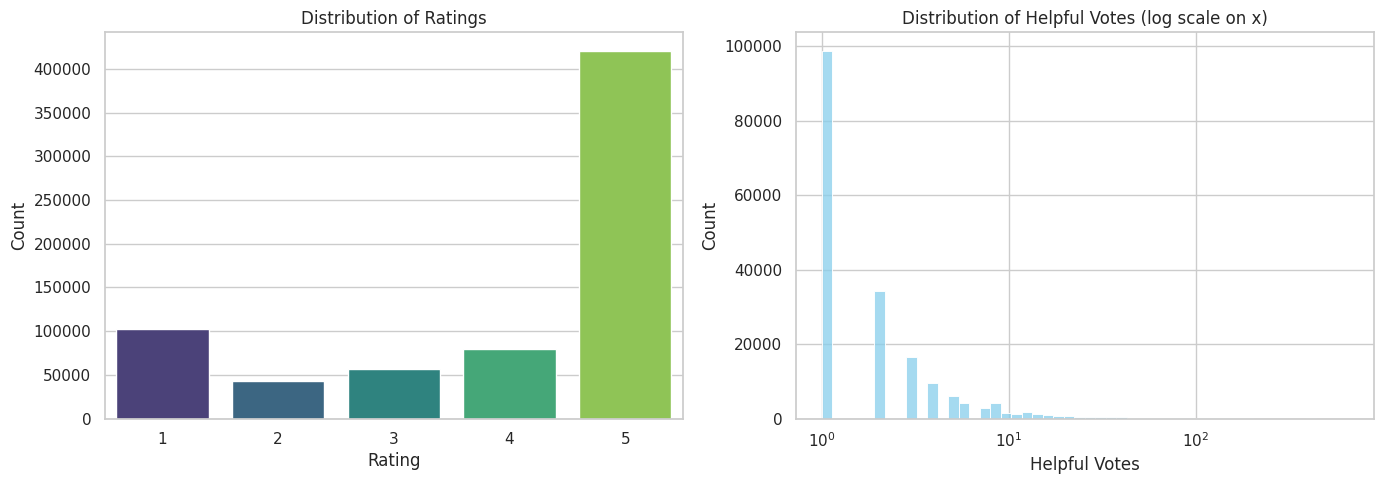

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
sns.set(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Ratings Distribution ---
sns.countplot(x="rating", data=df, ax=axes[0], palette="viridis")
axes[0].set_title("Distribution of Ratings")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

# --- Helpful Votes Distribution ---
sns.histplot(df["helpful_vote"], bins=50, ax=axes[1], log_scale=(True, False), color="skyblue")
axes[1].set_title("Distribution of Helpful Votes (log scale on x)")
axes[1].set_xlabel("Helpful Votes")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


### Ratings and Helpful Votes Distribution
The ratings distribution is highly skewed, with **5-star reviews dominating the dataset**, followed by a smaller but notable share of 1-star reviews.  
This imbalance suggests a tendency for users to leave feedback at the extremes (very satisfied or very dissatisfied).  

Helpful votes, on the other hand, are **heavily right-skewed**: most reviews receive few or no helpful votes, while only a small fraction gain significant attention.  
This highlights the "long tail" nature of engagement in product reviews.


Average characters per review: 173.03206714486095
Average words per review: 32.750866679590835


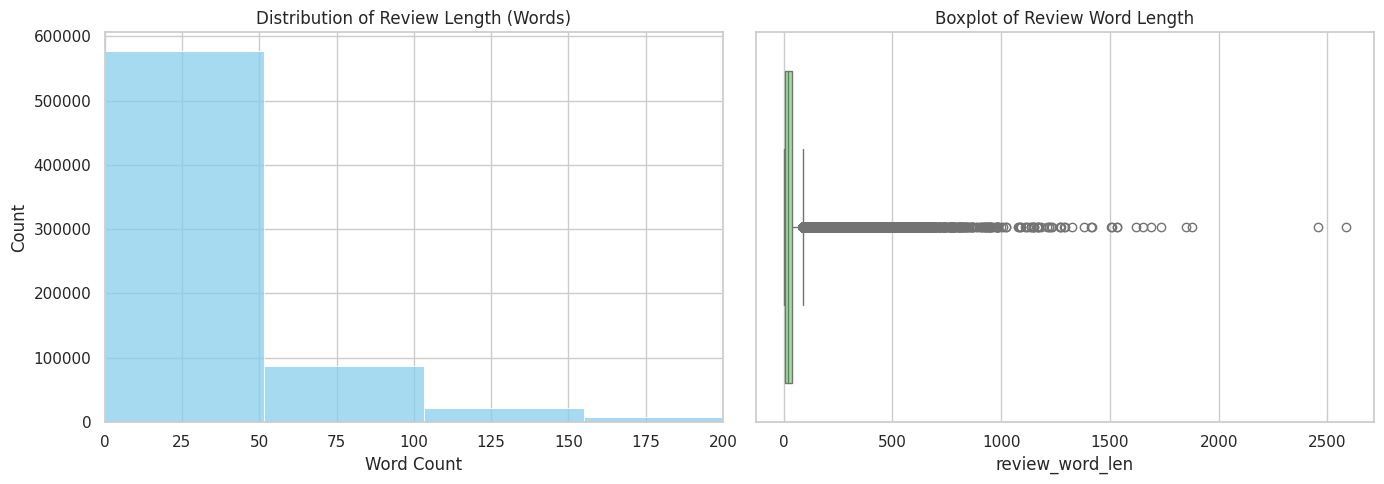

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Review length features ---
df["review_char_len"] = df["text"].astype(str).apply(len)
df["review_word_len"] = df["text"].astype(str).apply(lambda x: len(x.split()))

print("Average characters per review:", df["review_char_len"].mean())
print("Average words per review:", df["review_word_len"].mean())

# --- Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df["review_word_len"], bins=50, kde=False, color="skyblue", ax=axes[0])
axes[0].set_title("Distribution of Review Length (Words)")
axes[0].set_xlabel("Word Count")
axes[0].set_xlim(0, 200)  # zoom in to most reviews

sns.boxplot(x=df["review_word_len"], ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot of Review Word Length")

plt.tight_layout()
plt.show()


### Review Length Analysis
The majority of reviews are **short**, with most falling under 50 words.  
A few extremely long reviews (visible as outliers in the boxplot) stretch beyond 1000 words, but these are rare.  

This indicates that while most customers leave **concise feedback**, there is a small subset of highly detailed reviewers.  
The skewness in word counts suggests that **text-based modeling (e.g., sentiment analysis or topic modeling)** should account for this imbalance to avoid overemphasizing outlier reviews.


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/niranjanrao07/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/tmp/ipykernel_38976/4289013374.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


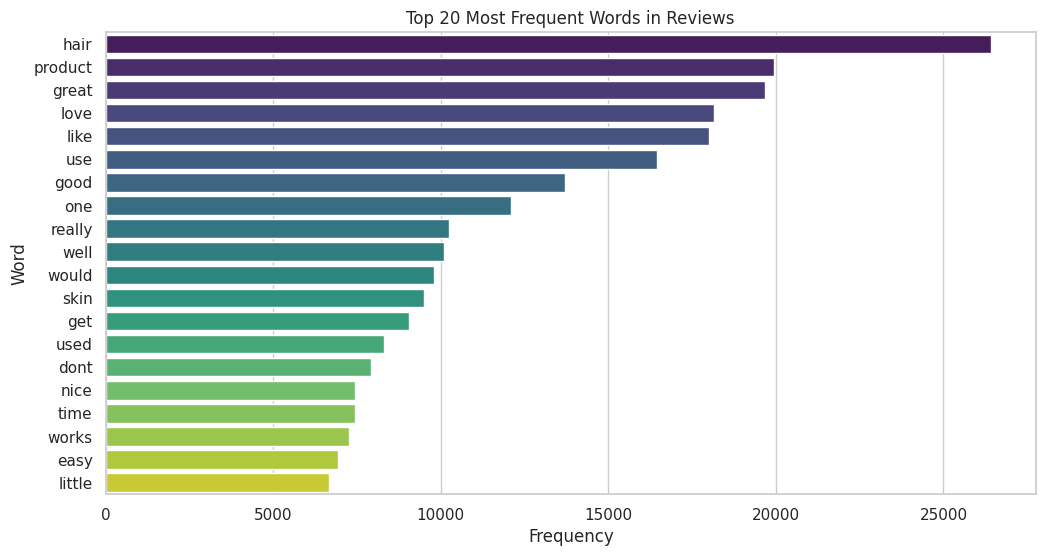

In [8]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# Tokenize + clean text
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)  # keep only letters
    words = text.split()
    return [w for w in words if w not in stop_words and len(w) > 2]

# Take a sample for speed
sample_texts = df["text"].dropna().sample(100000, random_state=42)

# Flatten tokens
all_words = []
for t in sample_texts:
    all_words.extend(tokenize(t))

# Count frequencies
word_counts = Counter(all_words)
common_words = word_counts.most_common(20)

# Plot
words, counts = zip(*common_words)
plt.figure(figsize=(12,6))
sns.barplot(x=list(counts), y=list(words), palette="viridis")
plt.title("Top 20 Most Frequent Words in Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()


### Frequent Words in Reviews
The top 20 most common words reveal strong themes in the dataset.  
Words like **“hair”, “product”, “great”, “love”** dominate, suggesting that many reviews revolve around **personal care and positive experiences**.  

Interestingly, terms such as **“skin”, “nice”, “works”, “easy”** also appear frequently, showing that customers often describe **usability and satisfaction**.  
The high frequency of positive words aligns with the skew towards higher star ratings observed earlier.


=== Average Sentiment Polarity by Rating ===
rating
1   -0.063366
2    0.055212
3    0.140401
4    0.258496
5    0.389469
Name: sentiment, dtype: float64


/tmp/ipykernel_38976/1615100048.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="rating", y="sentiment", data=sample_df, palette="viridis")


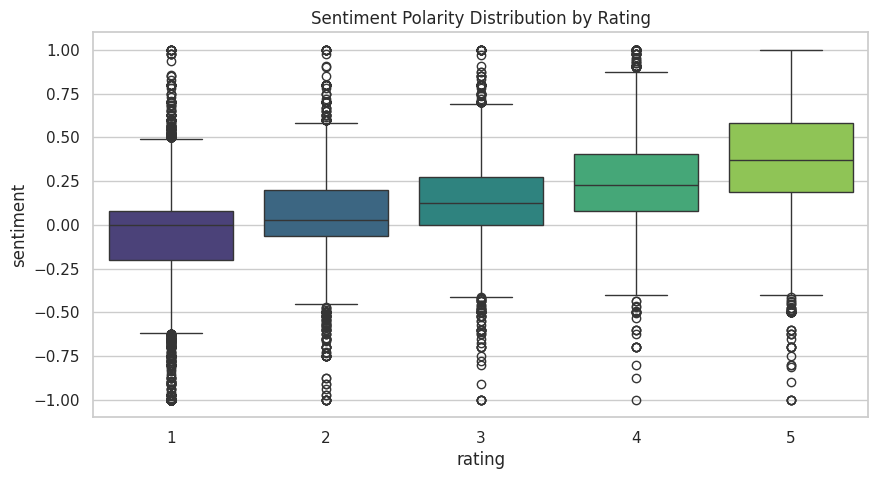

In [11]:
# --- Sentiment vs Rating Correlation ---

from textblob import TextBlob

# Compute sentiment polarity for a sample (for speed, not all rows)
sample_df = df.sample(50000, random_state=42).copy()
sample_df["sentiment"] = sample_df["text"].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

# Group by rating
sentiment_by_rating = sample_df.groupby("rating")["sentiment"].mean()

print("=== Average Sentiment Polarity by Rating ===")
print(sentiment_by_rating)

# Plot sentiment distribution across ratings
plt.figure(figsize=(10,5))
sns.boxplot(x="rating", y="sentiment", data=sample_df, palette="viridis")
plt.title("Sentiment Polarity Distribution by Rating")
plt.show()


### Sentiment vs Rating
The boxplot compares sentiment polarity of review text with the actual star ratings:  

- **Low ratings (1–2 stars)** → skewed toward **negative sentiment**, though some positive words still appear.  
- **Mid ratings (3 stars)** → show a mixed distribution, with both negative and positive reviews.  
- **High ratings (4–5 stars)** → strongly associated with **positive sentiment**, with higher medians and narrower variance.  

This confirms that the **text sentiment generally aligns with star ratings**, though not perfectly — indicating cases where reviewers might leave positive wording but lower ratings, or vice versa.


/tmp/ipykernel_38976/4187523911.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="timestamp", freq="M"))


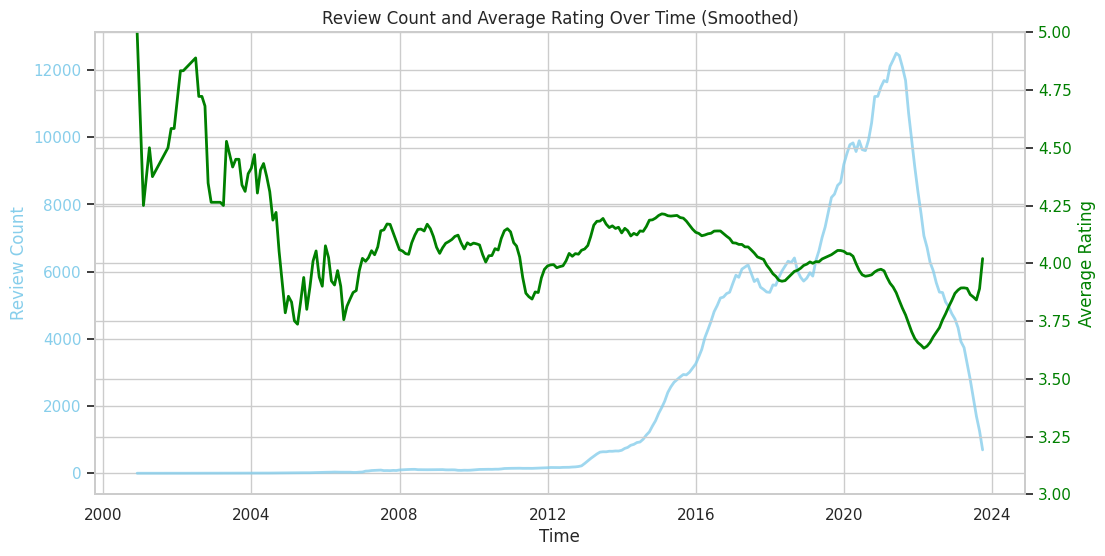

In [14]:
# Recompute monthly stats
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
monthly_stats = (
    df.groupby(pd.Grouper(key="timestamp", freq="M"))
    .agg({"rating": "mean", "asin": "count"})
    .rename(columns={"asin": "review_count"})
)

# Drop empty months
monthly_stats_clean = monthly_stats[monthly_stats["review_count"] > 0].copy()

# Apply smoothing (rolling averages, 6 months)
monthly_stats_clean["rating_smooth"] = (
    monthly_stats_clean["rating"].rolling(window=6, min_periods=1).mean()
)
monthly_stats_clean["review_count_smooth"] = (
    monthly_stats_clean["review_count"].rolling(window=6, min_periods=1).mean()
)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Review counts (smoothed)
color = "skyblue"
ax1.set_xlabel("Time")
ax1.set_ylabel("Review Count", color=color)
ax1.plot(
    monthly_stats_clean.index,
    monthly_stats_clean["review_count_smooth"],
    color=color,
    alpha=0.8,
    linewidth=2,
)
ax1.tick_params(axis="y", labelcolor=color)

# Ratings (smoothed)
ax2 = ax1.twinx()
color = "green"
ax2.set_ylabel("Average Rating", color=color)
ax2.plot(
    monthly_stats_clean.index,
    monthly_stats_clean["rating_smooth"],
    color=color,
    linewidth=2,
)
ax2.tick_params(axis="y", labelcolor=color)
ax2.set_ylim(3.0, 5.0)

plt.title("Review Count and Average Rating Over Time (Smoothed)")
plt.show()


### Review Trends Over Time
This visualization shows both **review volume** and **average ratings** across time:  

- **Review Count (blue line)** → increases sharply after 2014, peaks around 2020, and then drops significantly in recent years.  
- **Average Rating (green line)** → stays relatively stable (around 4.0) for much of the period but shows fluctuations, dipping slightly during periods of higher review activity.  
- The divergence between **review volume** and **average sentiment** suggests that product popularity spikes (more reviews) don’t always align with higher satisfaction — often, increased sales attract more critical feedback.  

Overall, this gives us insight into how consumer activity and satisfaction evolve together over time.


### Conclusion of EDA

From the exploratory data analysis of the Amazon Reviews dataset, we can summarize:  

- **Dataset Coverage:** Over 700K reviews across ~115K unique products, with a wide user base (~632K users).  
- **Ratings:** The distribution is highly skewed towards positive reviews — more than half of the reviews are 5-star.  
- **Helpful Votes:** Most reviews receive little to no helpful votes, though a small number of reviews gather hundreds, showing a long-tail effect.  
- **Text Analysis:** Reviews are generally short (average ~33 words). The most frequent words are related to beauty/personal care (e.g., “hair,” “product,” “great”), showing domain-specific vocabulary.  
- **Sentiment Analysis:** Text sentiment aligns with ratings — lower ratings tend to have more negative polarity, while higher ratings are associated with more positive sentiment.  
- **Temporal Trends:** Review activity surged after 2014 and peaked around 2020, but average ratings dipped slightly during high-volume periods, suggesting that more visibility also brings more critical opinions.  

**Key Takeaways:**  
The dataset demonstrates strong consumer bias toward positive reviews but also contains rich signals in review text, helpful votes, and temporal patterns. These insights can inform tasks like **sentiment prediction, product trend analysis, and recommendation systems**.
